In [1]:
import pandas as pd
import seaborn as sns
true = pd.read_csv('data/True.csv')
fake = pd.read_csv('data/Fake.csv')
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,31/12/17
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,29/12/17
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,31/12/17
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,30/12/17
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,29/12/17


In [2]:
true.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [3]:
true['label'] = 1
fake['label']=0
frames=[true.loc[:][:], fake.loc[:][:]]
df = pd.concat(frames)
df.tail()

,title,text,subject,date,label
23445,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,16/1/16,0
23446,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,16/1/16,0
23447,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,15/1/16,0
23448,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,14/1/16,0
23449,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,12/1/16,0


<Axes: xlabel='label', ylabel='count'>

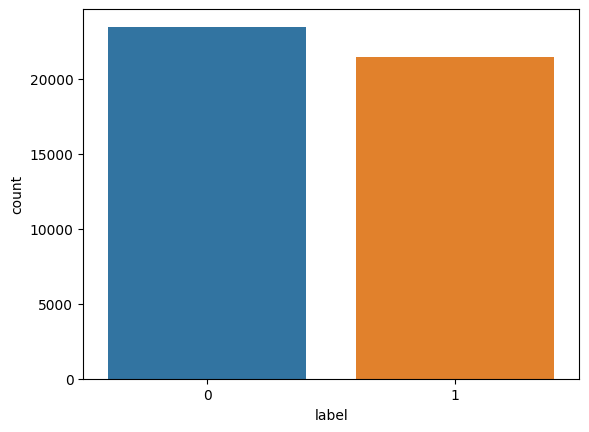

In [4]:
sns.countplot(data=df, x='label')

<Axes: xlabel='Year', ylabel='count'>

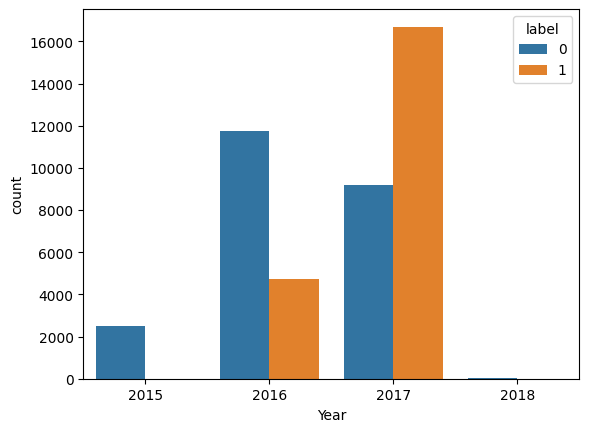

In [5]:
df['date']=pd.to_datetime(df['date'], errors = 'coerce')
df['Year']=df['date'].dt.year
df['Month'] = df['date'].dt.month
sns.countplot(data=df, x="Year", hue="label")

<Axes: xlabel='Year', ylabel='count'>

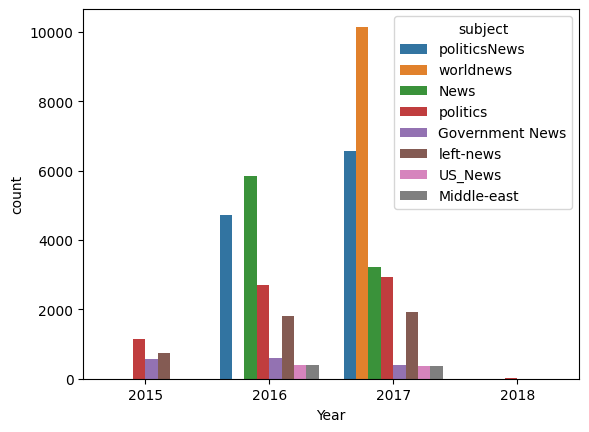

In [6]:
sns.countplot(data=df,x="Year", hue="subject")

In [7]:
frames = [true.head(200), fake.head(200)]
df=pd.concat(frames)
X=df.drop('label', axis=1)
y=df['label']

In [8]:
df= df.dropna()
df2 = df.copy()
df2.reset_index(inplace = True)
df2.tail()

,index,title,text,subject,date,label
395,195,Nursing Textbooks Recalled And Apology Issued...,"Pearson, an educational publishing company, is...",News,23/10/17,0
396,196,Trump SCREAMS On Twitter After Seeing A Poll ...,Rex Tillerson was right. Donald Trump is a f*c...,News,22/10/17,0
397,197,Trump And John Kelly Just Got RIPPED APART By...,Donald Trump and his disgraceful team deserve ...,News,21/10/17,0
398,198,NRA Releases Fascist Ad Calling All Trump Cri...,The First Amendment of the United States Const...,News,21/10/17,0
399,199,"Trump Takes Credit For Releasing JFK Files, B...","Saturday morning, Trump was going through his ...",News,21/10/17,0


In [14]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
import nltk

nltk.download('stopwords')
ps = PorterStemmer()
corpus = []
for i in range(0, len(df2)):
    review = re.sub('[^a-zA-Z]', ' ', df2['text'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_v = TfidfVectorizer()
X = tfidf_v.fit_transform(corpus).toarray()
y = df2['label']
X


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
classifier = LogisticRegression()
classifier.fit(X_train,y_train)
pred = classifier.predict(X_test)
score = metrics.accuracy_score(y_test,pred)
print("accuracy: %0.3f" % score)

accuracy: 0.950


Text(0.5, 1.0, 'confusion Matrix')

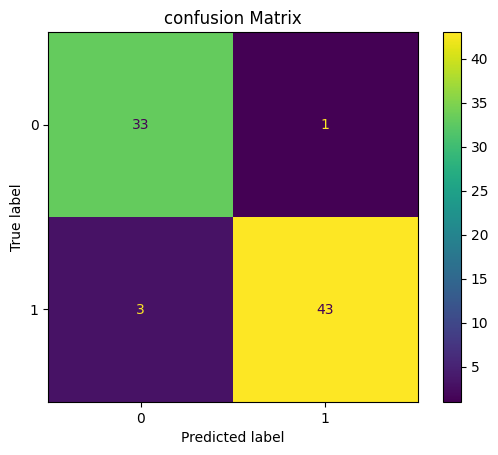

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_estimator(classifier, X_test,y_test)
disp.ax_.set_title("confusion Matrix")

In [20]:
import pickle
pickle.dump(classifier, open('model2.pkl', 'wb'))
pickle.dump(tfidf_v, open('tfidfvect2.pkl', 'wb'))

In [23]:
model = pickle.load(open('model2.pkl', 'rb'))
tdidfvect = pickle.load(open('tfidfvect2.pkl', 'rb'))

In [26]:
def predict(text):
    review = re.sub('[^a-zA-Z]', ' ', text)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    review_vect = tdidfvect.transform([review]).toarray()
    prediction = 'FAKE' if model.predict(review_vect) == 0 else 'REAL'
    return prediction

In [28]:
text = "Lindsey Graham Trashes Media For Portraying Trump As “Kooky”"
prediction = predict(text)
print(prediction)

FAKE
